# SLAM Occupancy-Grid Map Beautification

Turn a raw SLAM occupancy grid (ROS `map_server` `.pgm` + `.yaml`) into a clean, Manhattan-aligned
map that keeps the **actual scanned walls** (faithful — nothing invented or straightened, just
squared-up and evened).

1. **Preprocessing / denoising** — area-based despeckle (thin-wall safe)
2. **Morphology** — closing + a smoothed detection copy
3. **Manhattan alignment** — rotate so the dominant walls sit square
4. **Wall cleanup** — even the real wall pixels to a uniform width
5. **Region refinement** — interior *enclosed by walls* → white inside, grey outside
6. **Rendering** — grey outside · white inside · black faithful walls; export `.pgm`/`.yaml`

Requires: `opencv-python`, `numpy`, `matplotlib`, `pyyaml`.
```bash
pip install opencv-python numpy matplotlib pyyaml
```

In [15]:
import os
import numpy as np
import cv2
import yaml
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 9)

# --- Config: point this at a map from the repo (or your own SLAM output) ---
# ROS map_server writes a .pgm image + a .yaml sidecar with resolution/origin/thresholds.
MAP_YAML = os.path.expanduser('~/robot-fulfillment/amr/jetracer_ws/maps/test_map_outer_v6.yaml')
OUT_DIR  = os.path.expanduser('~/robot-fulfillment/amr/workstation_ws/src/slam_toolbox')
OUT_STEM = 'test_map_outer_v6_clean'

## Load the map

ROS `.pgm` convention (with `negate: 0`): white pixels are **free**, black are **occupied**,
mid-gray (~205) is **unknown**. We read the raw grayscale image and derive an occupancy
probability `p_occ = (255 - value) / 255`, then classify with the yaml's `occupied_thresh` /
`free_thresh` into the ROS convention: **free=0**, **occupied=100**, **unknown=-1**.

map: (256, 383) | resolution 0.05 m/px | origin [-8.31, -4.29, 0]
cells  free: 46718  occupied: 1541  unknown: 49789


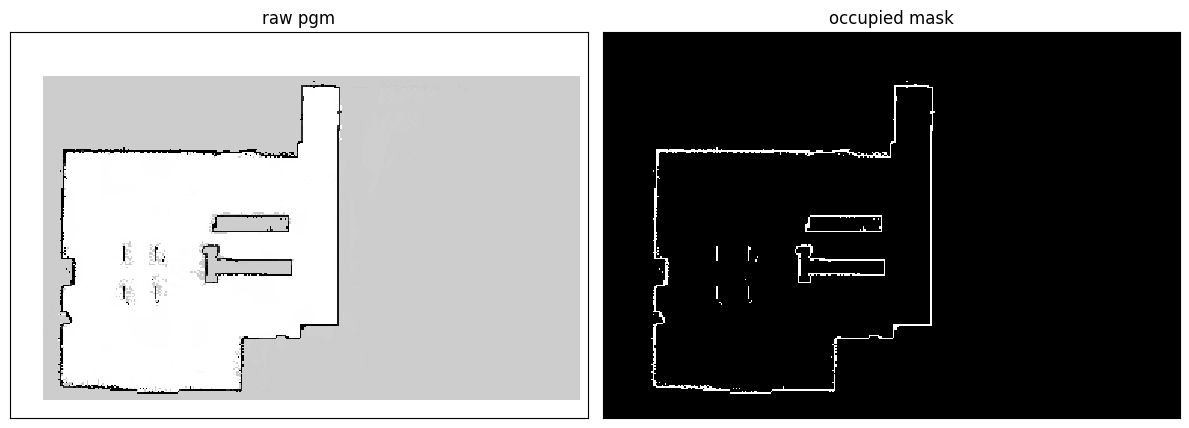

In [16]:
def load_ros_map(yaml_path):
    with open(yaml_path) as f:
        meta = yaml.safe_load(f)
    img_path = meta['image']
    if not os.path.isabs(img_path):
        img_path = os.path.join(os.path.dirname(yaml_path), img_path)
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(img_path)
    if int(meta.get('negate', 0)):
        gray = 255 - gray
    p_occ = (255.0 - gray.astype(np.float32)) / 255.0
    occ = np.full(gray.shape, -1, dtype=np.int8)          # unknown
    occ[p_occ >= meta['occupied_thresh']] = 100           # occupied
    # Free = clearly light cells. NOTE: for a trinary map the 'unknown' shade is
    # ~205, whose p_occ = (255-205)/255 = 0.196 sits BELOW free_thresh (0.25), so
    # a naive `p_occ <= free_thresh` mislabels unknown as free and the Step-5
    # flood-fill then leaks across the whole map. Require genuinely near-white so
    # the ~205 unknown shade stays unknown.
    free_cut = min(meta['free_thresh'], 0.10) if meta.get('mode', 'trinary') == 'trinary' else meta['free_thresh']
    occ[p_occ <= free_cut] = 0                            # free
    return gray, occ, meta

gray, occ, meta = load_ros_map(MAP_YAML)
print('map:', gray.shape, '| resolution', meta['resolution'], 'm/px | origin', meta['origin'])
print('cells  free:', int((occ==0).sum()),
      ' occupied:', int((occ==100).sum()),
      ' unknown:', int((occ==-1).sum()))

def show(*imgs, titles=None, cmap='gray'):
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1: axes = [axes]
    for ax, im in zip(axes, imgs):
        ax.imshow(im, cmap=cmap, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
    if titles:
        for ax, t in zip(axes, titles): ax.set_title(t)
    plt.tight_layout(); plt.show()

# Binary masks we will process. Occupied is the layer we clean the most.
occupied = (occ == 100).astype(np.uint8) * 255
free     = (occ == 0).astype(np.uint8) * 255
unknown  = (occ == -1).astype(np.uint8) * 255
show(gray, occupied, titles=['raw pgm', 'occupied mask'])

## Step 1 — Preprocessing / denoising (thin-wall safe)

**Watch out:** SLAM walls are often only **1–3 px wide**. A 3×3 **median filter** keeps a pixel
only if ≥ 5 of its 9 neighbors are set, and any **erosion** peels a pixel off every edge — either
one *deletes 1–2 px walls outright*, so the map appears to vanish. The cell below prints the wall
thickness so you can see this for your own map.

So we do **not** median-blur or erode the occupied layer. Instead we despeckle by
**connected-component area**: drop blobs smaller than `MIN_BLOB_PX`, which removes lone specks
while keeping thin walls fully intact.

wall half-thickness (px): median 1.0  max 1.9
98% of wall pixels are within 1 px of free space (very thin)
occupied px: 1541 -> 1516 after despeckle


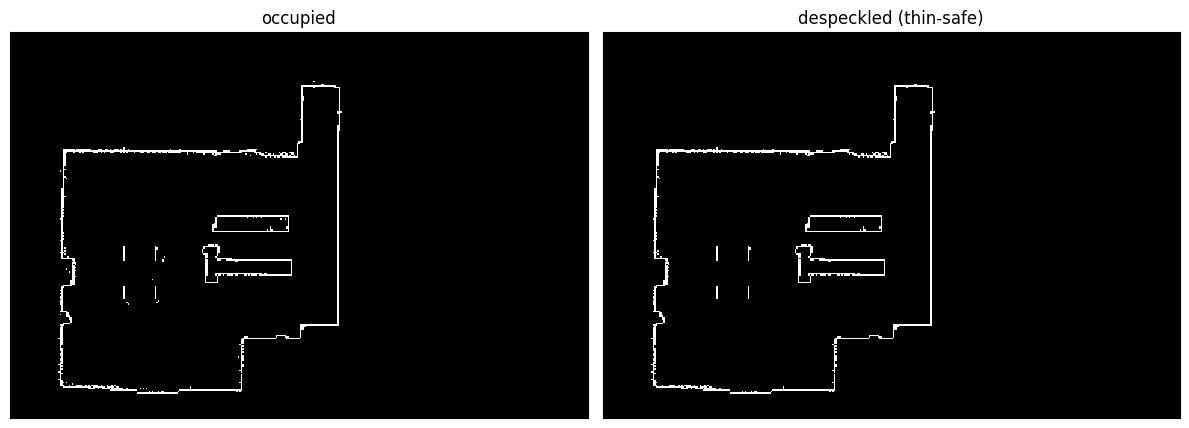

In [17]:
MIN_BLOB_PX = 4    # drop occupied blobs smaller than this (keep it small: thin walls!)

# Diagnostic: how thick are the walls? If this is ~1-3, erosion/median WILL erase them.
dist = cv2.distanceTransform(occupied, cv2.DIST_L2, 3)
edt = dist[occupied > 0]
print(f'wall half-thickness (px): median {np.median(edt):.1f}  max {edt.max():.1f}')
print(f'{100*(edt <= 1).mean():.0f}% of wall pixels are within 1 px of free space (very thin)')

def remove_speckles(mask, min_px):
    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for i in range(1, num):                       # 0 is background
        if stats[i, cv2.CC_STAT_AREA] >= min_px:
            out[labels == i] = 255
    return out

# Area-based despeckle only -- NO median blur, NO erosion on the thin occupied layer.
den = remove_speckles(occupied, MIN_BLOB_PX)
print(f'occupied px: {int((occupied>0).sum())} -> {int((den>0).sum())} after despeckle')
show(occupied, den, titles=['occupied', 'despeckled (thin-safe)'])

## Step 2 — Morphology + smoothed detection copy

- **Closing** (dilate → erode) fills small gaps so broken wall segments reconnect, without eroding
  thin walls. This `morph` is the **faithful** cleaned wall layer used for the final map.
- A separate **thickened + smoothed** copy is made *only for detection* (the Manhattan-angle
  estimate in Step 3): thickening gives Hough enough support, and smoothing (close + median)
  removes the jagged scan edges that would otherwise skew the dominant-angle estimate.

occupied px: 1516 -> 1586 (closed)


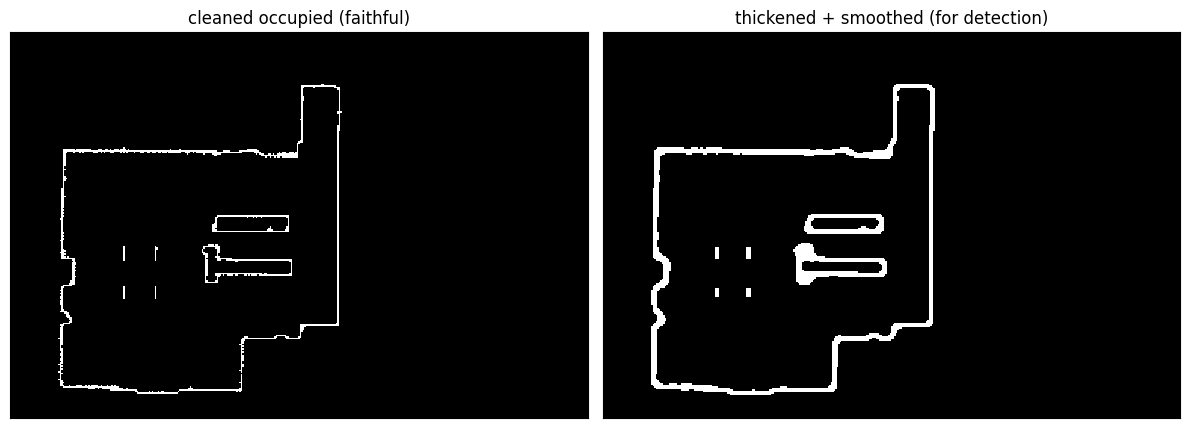

In [18]:
k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

morph = cv2.morphologyEx(den, cv2.MORPH_CLOSE, k3)   # faithful cleaned walls (thin)

# Detection copy: thicken for Hough support, then SMOOTH (close + median) so the
# ragged scan edges don't skew the Manhattan-angle estimate. Detection/analysis only.
thick = cv2.dilate(morph, k3, iterations=1)
thick = cv2.morphologyEx(thick, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
thick = cv2.medianBlur(thick, 5)                     # smooth jagged edges
print(f'occupied px: {int((den>0).sum())} -> {int((morph>0).sum())} (closed)')
show(morph, thick, titles=['cleaned occupied (faithful)', 'thickened + smoothed (for detection)'])

## Step 3 — Manhattan alignment

Estimate the building's dominant wall direction (length-weighted Hough angle on the smoothed
detection copy) and compute the rotation that squares the walls to the image axes. The estimate is
**self-correcting**: cv2's rotation sign vs. our y-down angle convention is easy to get backwards,
so we try both candidate rotations and keep whichever actually leaves the walls closest to
axis-aligned. Everything downstream works in this aligned frame.

Manhattan rotation: +0.50 deg (residual wall tilt: 0.50 deg)


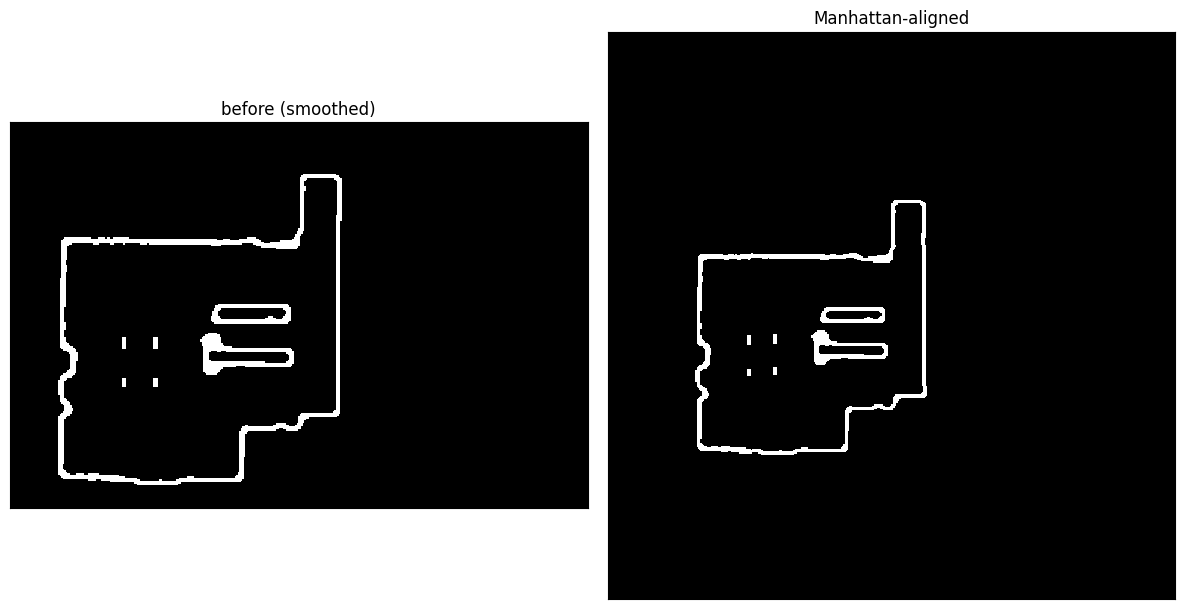

In [19]:
def rotate_mask(mask, angle_deg):
    # Rotate into a FIXED square canvas (side = image diagonal), centered -- i.e.
    # pad symmetrically. Same size for any angle, and big enough that rotation
    # never clips a corner. Returns the warp matrix M for later inverse-warp.
    h, w = mask.shape
    S = int(np.ceil(np.hypot(h, w)))
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    M[0, 2] += (S - w) / 2
    M[1, 2] += (S - h) / 2
    return cv2.warpAffine(mask, M, (S, S), flags=cv2.INTER_NEAREST, borderValue=0), M

def modal_wall_angle(mask):
    """Length-weighted dominant wall orientation, folded into [0, 90)."""
    L = cv2.HoughLinesP(mask, 1, np.pi/180, threshold=40, minLineLength=20, maxLineGap=6)
    if L is None:
        return None
    L = L.reshape(-1, 4)
    ang = np.rad2deg(np.arctan2(L[:, 3] - L[:, 1], L[:, 2] - L[:, 0])) % 90.0
    length = np.hypot(L[:, 2] - L[:, 0], L[:, 3] - L[:, 1])
    hist, edges = np.histogram(ang, bins=90, range=(0, 90), weights=length)
    return (edges[hist.argmax()] + edges[hist.argmax() + 1]) / 2

def alignment_rotation(mask):
    """Degrees to rotate so the dominant walls sit on the image axes. Tries both
    candidate rotations and keeps whichever leaves the walls closest to square."""
    base = modal_wall_angle(mask)
    if base is None:
        return 0.0
    best, best_residual = 0.0, 1e9
    for cand in (base, base - 90.0):
        r, _ = rotate_mask(mask, cand)
        res = modal_wall_angle(r)
        res = min(res, 90 - res)            # distance to the nearest axis
        if res < best_residual:
            best, best_residual = cand, res
    return best

theta = alignment_rotation(thick)           # detect on the smoothed copy
residual = modal_wall_angle(rotate_mask(thick, theta)[0]) % 90
print(f'Manhattan rotation: {theta:+.2f} deg (residual wall tilt: {min(residual, 90-residual):.2f} deg)')

show(thick, rotate_mask(thick, theta)[0], titles=['before (smoothed)', 'Manhattan-aligned'])

## Step 4 — Wall cleanup (faithful, aligned)

Rotate the **faithful** cleaned walls (`morph`) into the Manhattan-aligned frame, then even their
width so they read tidily. We keep the *actual scanned pixels* — nothing is vectorized or moved —
they're just squared-up and given a uniform thickness.

wall pixels: 1586 -> 3835 (evened to ~3px)


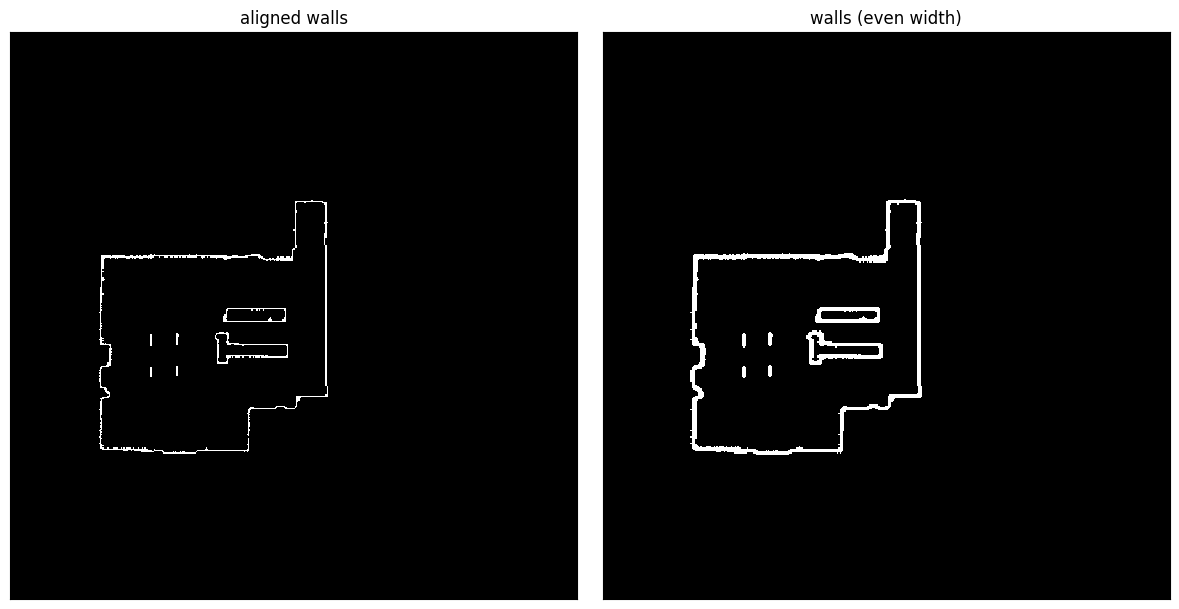

In [20]:
WALL_WIDTH = 3   # target wall thickness (px)

aligned_morph, M = rotate_mask(morph, theta)     # faithful walls, now squared

# Bridge tiny gaps, then set an even minimum thickness (still the real pixels).
wall_mask = cv2.morphologyEx(aligned_morph, cv2.MORPH_CLOSE,
                             cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
wall_mask = cv2.dilate(wall_mask,
                       cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (WALL_WIDTH, WALL_WIDTH)))
print(f'wall pixels: {int((aligned_morph>0).sum())} -> {int((wall_mask>0).sum())} (evened to ~{WALL_WIDTH}px)')
show(aligned_morph, wall_mask, titles=['aligned walls', 'walls (even width)'])

## Step 5 — Region refinement (interior enclosed by walls)

Goal: **white inside the walls, grey outside** — the previous free-space method turned observed-free
areas *outside* the room white too. Instead we define the interior from the **walls**:

1. **Close** the walls with a larger kernel to bridge doorways / small openings into a closed boundary.
2. **Flood the exterior** inward from the canvas corner; everything it can't reach is the interior.
3. Interior = enclosed region (furniture and unknown pockets included) → **solid white**; everything
   the flood reached stays **grey**. `BOUND_CLOSE` sets how wide an opening still counts as "closed".

interior covers 14% of the aligned canvas (OK)


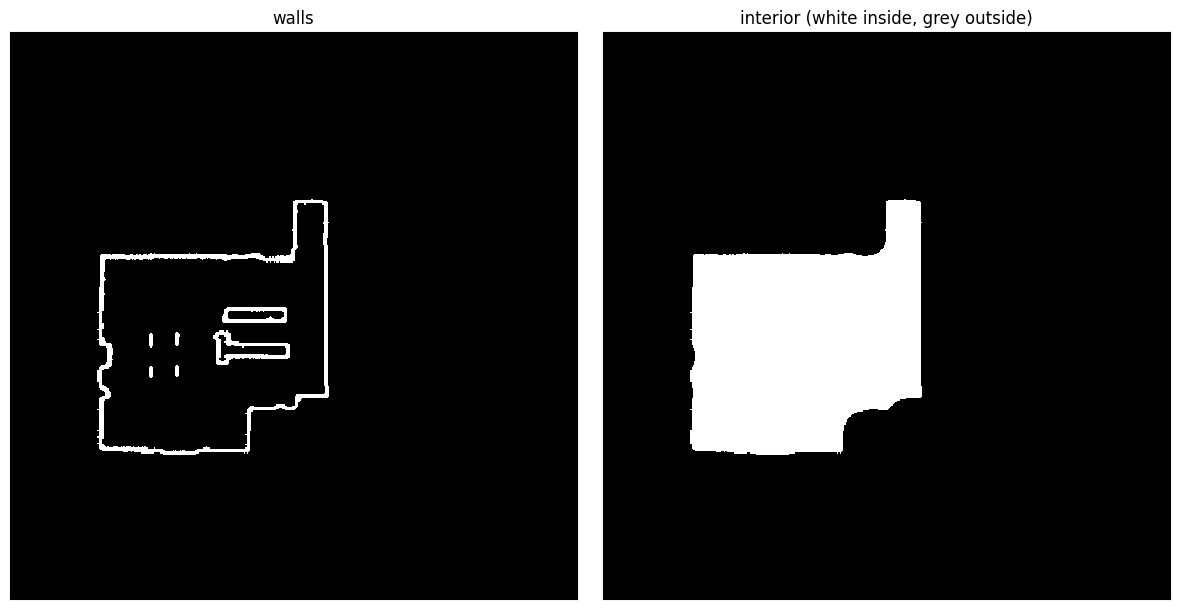

In [21]:
BOUND_CLOSE = 31   # px; bridge wall openings up to ~this wide to close the boundary

# 1) Close the walls into a boundary loop.
boundary = cv2.morphologyEx(wall_mask, cv2.MORPH_CLOSE,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (BOUND_CLOSE, BOUND_CLOSE)))

# 2) Flood the non-wall space from the (always-exterior) canvas corner.
walk = (boundary == 0).astype(np.uint8) * 255
flood = walk.copy()
cv2.floodFill(flood, np.zeros((walk.shape[0] + 2, walk.shape[1] + 2), np.uint8), (0, 0), 0)
exterior = (walk > 0) & (flood == 0)               # non-wall AND reached from the border

# 3) Interior = everything not exterior-open (enclosed area + walls) -> solid.
interior_filled = (~exterior).astype(np.uint8) * 255
frac = (interior_filled > 0).mean()
print(f'interior covers {100*frac:.0f}% of the aligned canvas',
      '(OK)' if 0.05 < frac < 0.9 else '(!! walls may not enclose -- adjust BOUND_CLOSE)')
show(wall_mask, interior_filled, titles=['walls', 'interior (white inside, grey outside)'])

## Step 6 — Rendering & export

Compose the final map: unknown **grey (205)** outside, solid **white (254)** inside the walls, then
the faithful **black (0)** walls on top — Manhattan-aligned.

- `EXPORT_ALIGNED = True` saves the squared frame (walls sit straight). Size is the padded square and
  the saved `origin` is not metric (grid is rotated) — best as a floor-plan picture.
- `EXPORT_ALIGNED = False` inverse-warps back onto the original raster (same size / `origin` as the
  input `.yaml`) for a Nav2 drop-in; walls then sit at their true orientation.

output size (w x h): 461 x 461 | input was: 383 x 256


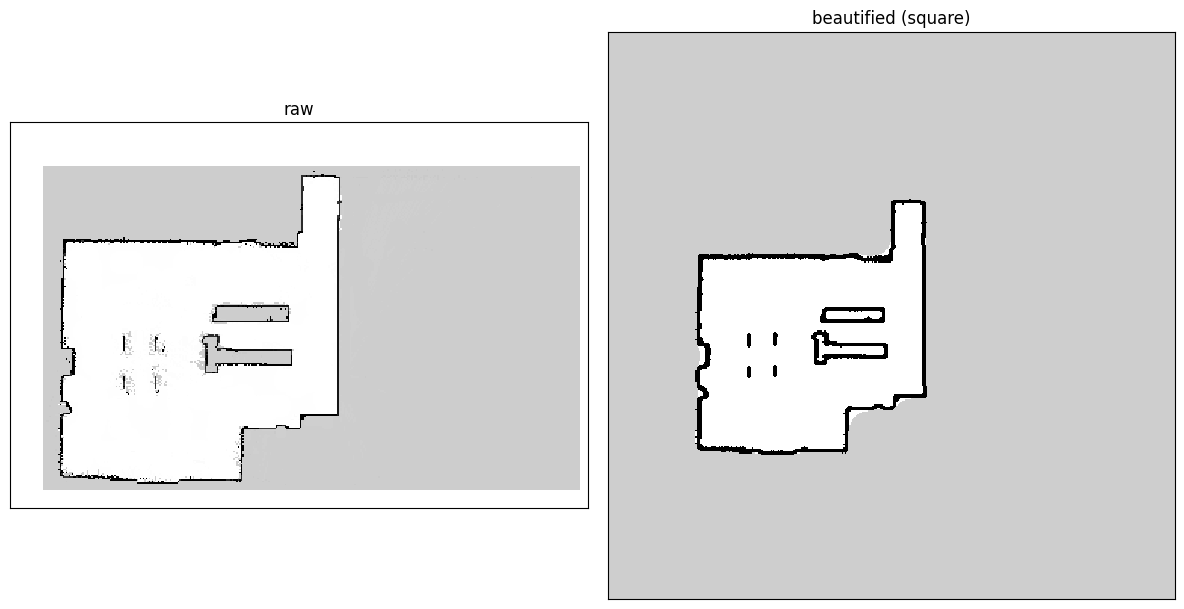

wrote: /home/apc/robot-fulfillment/amr/workstation_ws/src/slam_toolbox/test_map_outer_v6_clean.pgm
wrote: /home/apc/robot-fulfillment/amr/workstation_ws/src/slam_toolbox/test_map_outer_v6_clean.png
wrote: /home/apc/robot-fulfillment/amr/workstation_ws/src/slam_toolbox/test_map_outer_v6_clean.yaml


In [22]:
EXPORT_ALIGNED = True    # True: Manhattan-square picture. False: original frame (Nav2 drop-in).

canvas = np.full(wall_mask.shape, 205, np.uint8)   # unknown (grey) outside
canvas[interior_filled > 0] = 254                   # free (white) inside the walls
canvas[wall_mask > 0] = 0                            # faithful walls (black) on top

if EXPORT_ALIGNED:
    clean = canvas                                  # padded, squared frame
else:
    orig_h, orig_w = gray.shape                     # back onto the original raster
    clean = cv2.warpAffine(canvas, M, (orig_w, orig_h),
                           flags=cv2.INTER_NEAREST | cv2.WARP_INVERSE_MAP, borderValue=205)
print('output size (w x h):', clean.shape[1], 'x', clean.shape[0],
      '| input was:', gray.shape[1], 'x', gray.shape[0])
show(gray, clean, titles=['raw', 'beautified (square)' if EXPORT_ALIGNED else 'beautified (orig frame)'])

os.makedirs(OUT_DIR, exist_ok=True)
pgm_path = os.path.join(OUT_DIR, OUT_STEM + '.pgm')
png_path = os.path.join(OUT_DIR, OUT_STEM + '.png')
yaml_path = os.path.join(OUT_DIR, OUT_STEM + '.yaml')
cv2.imwrite(pgm_path, clean)
cv2.imwrite(png_path, clean)

out_meta = dict(meta)
out_meta['image'] = os.path.basename(pgm_path)
with open(yaml_path, 'w') as f:
    yaml.safe_dump(out_meta, f, default_flow_style=None, sort_keys=False)
print('wrote:', pgm_path)
print('wrote:', png_path)
print('wrote:', yaml_path)

## Step 7 — Vector (SVG) export — the nice map to show the user

The `.pgm`/`.png` above are raster: zoom in and you see pixels. For a **crisp, scalable** map to
put in front of a user (docs, a slide, a web view), *vectorize* the cleaned masks: trace the
interior and the walls into polygons and write an **SVG**.

- Traces the exact same `interior_filled` / `wall_mask` from Steps 5–6, so the SVG matches the raster
  map — just as scalable vectors, grey outside · white inside · near-black walls.
- `SIMPLIFY_EPS` (Douglas–Peucker, px) tidies the jagged pixel staircase; **0** keeps every step,
  higher smooths more. Holes (interior pockets, doorways) are handled with `fill-rule:evenodd`.
- Renders inline below and writes `<OUT_STEM>.svg` next to the other exports.

wrote: /home/apc/robot-fulfillment/amr/workstation_ws/src/slam_toolbox/test_map_outer_v6_clean.svg  (4.7 KB, 1 interior + 10 wall paths)


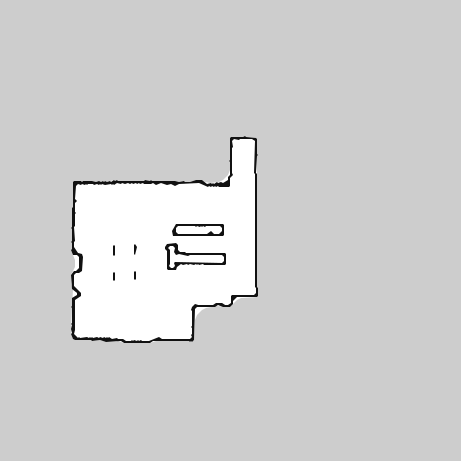

In [23]:
# Vectorize the cleaned masks into crisp SVG polygons (scales with no pixelation).
SIMPLIFY_EPS = 0.8   # px; Douglas-Peucker tolerance for tidier vector edges (0 = keep every pixel step)
SVG_SCALE    = 1.0   # SVG user-units per source pixel

def mask_to_paths(mask, eps):
    """Trace a binary mask into SVG subpath strings. Outer boundaries + inner holes
    are emitted together and rendered with fill-rule:evenodd, so holes punch through."""
    cnts, _ = cv2.findContours(mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    subs = []
    for c in cnts:
        if eps > 0:
            c = cv2.approxPolyDP(c, eps, True)      # simplify jagged pixel steps
        if len(c) < 3:
            continue                                 # skip degenerate specks
        pts = c.reshape(-1, 2)
        subs.append('M ' + ' L '.join(f'{x} {y}' for x, y in pts) + ' Z')
    return subs

# Vectorize on the SAME aligned masks the raster export used (Step 5/6), so the
# SVG matches the .pgm exactly -- just as vectors instead of pixels.
h, w = wall_mask.shape
white_paths = mask_to_paths((interior_filled > 0).astype(np.uint8) * 255, SIMPLIFY_EPS)
wall_paths  = mask_to_paths((wall_mask       > 0).astype(np.uint8) * 255, SIMPLIFY_EPS)

svg = (
    f'<svg xmlns="http://www.w3.org/2000/svg" width="{w*SVG_SCALE:g}" height="{h*SVG_SCALE:g}" '
    f'viewBox="0 0 {w} {h}" shape-rendering="geometricPrecision">\n'
    f'  <rect width="{w}" height="{h}" fill="#cdcdcd"/>\n'                                    # unknown / outside (grey 205)
    f'  <path fill="#ffffff" fill-rule="evenodd" d="{" ".join(white_paths)}"/>\n'            # interior (white)
    f'  <path fill="#111111" fill-rule="evenodd" d="{" ".join(wall_paths)}"/>\n'             # walls (near-black)
    f'</svg>\n'
)

svg_path = os.path.join(OUT_DIR, OUT_STEM + '.svg')
with open(svg_path, 'w') as f:
    f.write(svg)
print(f'wrote: {svg_path}  ({len(svg)/1024:.1f} KB, '
      f'{len(white_paths)} interior + {len(wall_paths)} wall paths)')

# Inline preview -- this is the crisp, scalable map to show the user.
from IPython.display import SVG, display
display(SVG(svg))

## Step 7b — Robot-vacuum app style (iRobot / Roborock look)

Same vectors, restyled to look like a consumer robot-vacuum app: **soft blue floor**, a **blocky
grid-stepped blue outline** (squarish, right-angle staircase — *not* smoothed), interior obstacles as
blue blocks, on a light background.

- The pixelated look comes from `coarsen()`, which snaps the masks to a **`BLOCK`-px cell grid** before
  tracing — bigger `BLOCK` = chunkier pixels (try 2–6). Contours use no simplification, so edges stay
  axis-aligned; `shape-rendering="crispEdges"` keeps them hard.
- `APP_FLOOR` / `APP_OUTLINE` / `APP_BG` set the palette. Writes `<OUT_STEM>_app.svg`.
- **Per-room colors & labels** (like the screenshot's "Kitchen", "Living room") need *room
  segmentation* — splitting the floor at doorways and naming each region. Our test map is one open
  area, so it renders as a single room; say the word and I'll add a segmentation + labeling pass.

In [ ]:
# Robot-vacuum app styling: soft blue floor, blocky grid-stepped blue walls, light bg.
APP_BG       = '#eef1f5'   # light background
APP_FLOOR    = '#bcd6f0'   # soft blue floor fill
APP_OUTLINE  = '#4a90d9'   # medium-blue walls
BLOCK        = 2           # px per grid cell -- bigger = chunkier "pixels" (try 2-6)
APP_PAD      = 14          # px breathing room around the map

def coarsen(mask, block, cov):
    """Snap a mask to a BLOCK-px cell grid: each cell is on when >= cov of it is set.
    This is what makes the edges squarish/pixelated instead of smooth."""
    h, w = mask.shape
    small = cv2.resize(mask, (w // block, h // block), interpolation=cv2.INTER_AREA)
    return (small >= cov * 255).astype(np.uint8) * 255

def blocky_paths(cmask, block):
    """Axis-aligned stepped contours at cell resolution, scaled back to full px.
    No approxPolyDP / no smoothing -- keep the right-angle staircase."""
    cnts, _ = cv2.findContours(cmask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    subs = []
    for c in cnts:
        pts = c.reshape(-1, 2) * block
        if len(pts) < 3:
            continue
        subs.append('M ' + ' L '.join(f'{x} {y}' for x, y in pts) + ' Z')
    return subs

h, w = wall_mask.shape
floor_cells = coarsen((interior_filled > 0).astype(np.uint8) * 255, BLOCK, 0.5)
wall_cells  = coarsen((wall_mask       > 0).astype(np.uint8) * 255, BLOCK, 0.25)  # low cov keeps thin walls
floor_paths = blocky_paths(floor_cells, BLOCK)
wall_paths2 = blocky_paths(wall_cells,  BLOCK)

W, H = w + 2*APP_PAD, h + 2*APP_PAD
app_svg = (
    f'<svg xmlns="http://www.w3.org/2000/svg" width="{W}" height="{H}" '
    f'viewBox="{-APP_PAD} {-APP_PAD} {W} {H}" shape-rendering="crispEdges">\n'
    f'  <rect x="{-APP_PAD}" y="{-APP_PAD}" width="{W}" height="{H}" fill="{APP_BG}"/>\n'
    # floor: soft blue fill only -- NO stroke (the wall fill below is the single blue line)
    f'  <path d="{" ".join(floor_paths)}" fill="{APP_FLOOR}" fill-rule="evenodd"/>\n'
    # walls / furniture: solid blue blocks on top -- the one and only blue line
    f'  <path d="{" ".join(wall_paths2)}" fill="{APP_OUTLINE}" fill-rule="evenodd"/>\n'
    f'</svg>\n'
)

app_path = os.path.join(OUT_DIR, OUT_STEM + '_app.svg')
with open(app_path, 'w') as f:
    f.write(app_svg)
print(f'wrote: {app_path}  ({len(app_svg)/1024:.1f} KB, BLOCK={BLOCK}px)')

from IPython.display import SVG, display
display(SVG(app_svg))

## Step 8 — Export to the orchestrator (coordinate-retaining)

Write the cleaned map into the `robot_web_bridge` config so the live admin editor serves it. This
uses the **original-frame** export (`EXPORT_ALIGNED = False` semantics): the cleaned canvas is
inverse-warped back onto the input raster, so **size, `origin` and `resolution` are unchanged** and
dock/obstacle poses stay exactly where the robot navigates.

The web bridge does the rest at request time — blue "app" styling and the squared *view* (a
display-only rotation) — with `ROBOT_WEB_BRIDGE_MAP_STYLE=app`. Only the `.pgm` is overwritten; an
existing `slam_map.yaml` is preserved so the operator's origin / `display_rotation_deg` survive.

In [ ]:
# Export the cleaned map to the orchestrator, in the ORIGINAL frame (coords retained).
# This is the offline compute the robot_web_bridge serves: it inverse-warps the cleaned
# canvas back onto the input raster (same as EXPORT_ALIGNED=False), so origin/resolution
# stay metric-valid. We write BOTH:
#   - slam_map.pgm : cleaned occupancy grid (Nav2 / coordinate source of truth)
#   - slam_map.svg : EXACTLY the Step-7b app render (blocky, BLOCK=2, same palette), just
#                    built on the original-frame masks with NO padding so viewBox = the
#                    pixel grid and it stretches over the world bounds like the .pgm.
# The web bridge serves the .svg as-is (ROBOT_WEB_BRIDGE_MAP_STYLE=app) and squares the
# *view* via a display-only rotation -- pixels are never rotated, coordinates unchanged.
ORCH_CONFIG = os.path.expanduser('~/robot-fulfillment/orchestrator/src/robot_web_bridge/config')
ORCH_STEM   = 'slam_map'

orig_h, orig_w = gray.shape
clean_orig = cv2.warpAffine(canvas, M, (orig_w, orig_h),
                            flags=cv2.INTER_NEAREST | cv2.WARP_INVERSE_MAP, borderValue=205)

orch_pgm  = os.path.join(ORCH_CONFIG, ORCH_STEM + '.pgm')
orch_yaml = os.path.join(ORCH_CONFIG, ORCH_STEM + '.yaml')
orch_svg  = os.path.join(ORCH_CONFIG, ORCH_STEM + '.svg')
cv2.imwrite(orch_pgm, clean_orig)          # same size/frame as the input -> world bounds unchanged

# Keep an existing sidecar as-is (preserves the operator's origin + display_rotation_deg);
# only write a fresh one if none exists. NOTE: assumes this notebook's input map shares the
# orchestrator map's origin/resolution (it does -- both are test_map_outer_v6).
if os.path.exists(orch_yaml):
    print('kept existing', orch_yaml, '(origin/resolution/display settings preserved)')
else:
    m = dict(meta); m['image'] = ORCH_STEM + '.pgm'
    with open(orch_yaml, 'w') as f:
        yaml.safe_dump(m, f, default_flow_style=None, sort_keys=False)
    print('wrote', orch_yaml)

# Reuse Step 7b's coarsen()/blocky_paths() + palette/BLOCK, on the ORIGINAL-frame masks.
# Floor = the ENCLOSED region (interior + walls, i.e. everything not the grey-205 outside),
# so the floor fill runs UNDER the walls -- matches 7b's interior_filled and leaves no gap.
# Wall fill on top is the single blue line (NO stroke -> no double-rendering).
floor_o = (clean_orig != 205).astype(np.uint8) * 255     # enclosed = interior + walls
wall_o  = (clean_orig <= 10).astype(np.uint8) * 255        # walls
floor_cells = coarsen(floor_o, BLOCK, 0.5)
wall_cells  = coarsen(wall_o,  BLOCK, 0.25)               # low cov keeps thin walls
fp = blocky_paths(floor_cells, BLOCK)
wp = blocky_paths(wall_cells,  BLOCK)
out_svg = (
    f'<svg xmlns="http://www.w3.org/2000/svg" width="{orig_w}" height="{orig_h}" '
    f'viewBox="0 0 {orig_w} {orig_h}" shape-rendering="crispEdges">'
    f'<rect width="{orig_w}" height="{orig_h}" fill="{APP_BG}"/>'
    f'<path d="{" ".join(fp)}" fill="{APP_FLOOR}" fill-rule="evenodd"/>'
    f'<path d="{" ".join(wp)}" fill="{APP_OUTLINE}" fill-rule="evenodd"/>'
    f'</svg>'
)
with open(orch_svg, 'w') as f:
    f.write(out_svg)

print('wrote', orch_pgm, '| wrote', orch_svg, f'({len(out_svg)/1024:.1f} KB, BLOCK={BLOCK})')
print('size', clean_orig.shape[::-1], '| origin', meta['origin'], '| resolution', meta['resolution'],
      '-> coordinates retained')
show(gray, clean_orig, titles=['raw (orchestrator input)', 'cleaned, original frame (served)'])
from IPython.display import SVG, display
display(SVG(out_svg))

## Notes & tuning

- **Faithful + aligned**: walls are the real cleaned occupied pixels (Steps 1–2), rotated square in
  Step 3 and evened in Step 4 — never vectorized or moved.
- **Key knobs**: `MIN_BLOB_PX` (Step 1, speckle removal), the smoothing kernels in Step 2 (detection
  angle), `WALL_WIDTH` (Step 4, thickness), `BOUND_CLOSE` (Step 5, how wide an opening still counts
  as an enclosed room), `EXPORT_ALIGNED` (Step 6, square picture vs. Nav2 original-frame).
- **White inside / grey outside** comes from defining the interior as the region *enclosed by the
  walls* (Step 5), not the observed free space — so observed-free areas outside the room stay grey.
  If the room's boundary has a wide real opening, raise `BOUND_CLOSE` to bridge it; if separate rooms
  merge, lower it.
- **Nav2 use**: set `EXPORT_ALIGNED = False` to write the map in the original frame/size with the
  input `origin` (metric-valid). The square export is a floor-plan picture whose `origin` isn't metric.
- **Learning-based option**: a U-Net / GAN trained on raw→clean pairs can go further with labeled data.